In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

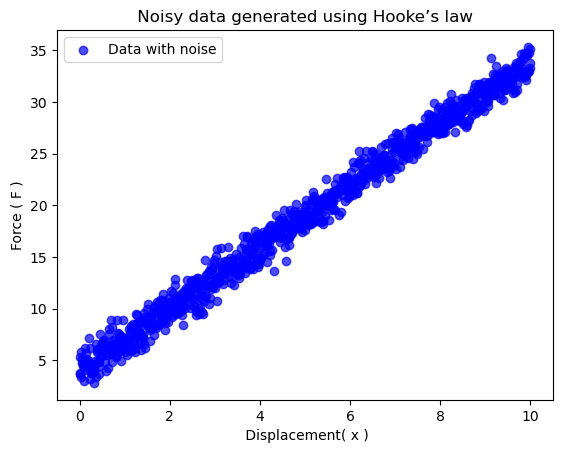

 In - sample error ( E_in ):1.1023122032926886
 Out - of - sample error ( E_out ):0.9473540161335786


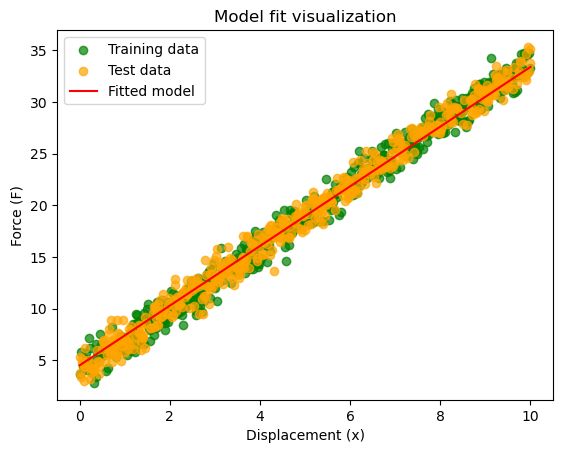

In [ ]:
sigma = 1
N = 1000 # Number of data points
# Generate data
x = np.linspace (0 , 10 , N )
noise = np.random.normal (0 , sigma , N )
F = 4 + 3*x + noise

# Split the data
x_train,x_test,F_train,F_test = train_test_split(x , F , test_size =0.5 , random_state =42)
# Plot data
plt.scatter(x ,F, label = "Data with noise", color = "blue", alpha =0.7)
plt.xlabel(" Displacement( x )")
plt.ylabel("Force ( F )")
plt.title(" Noisy data generated using Hooke’s law ")
plt.legend()
plt.show()

poly = PolynomialFeatures(degree =1) #Establecemos un polinomio de grado 1, Su utilidad principal aquí es que añade automáticamente una columna de "unos" 
#(1) que sirve para calcular el "intercepto" (la b en la ecuacióny=mx+b)

x_train_poly = poly.fit_transform(x_train.reshape( -1 , 1)) #Reshape converts our data from row --> colum //     
#Fit (Aprender): La máquina poly mira los datos para ver cómo son. Transform (Transformar): 
# Aplica el cambio (añade la columna de unos y ajusta el formato). El resultado se guarda en x_train_poly.

x_test_poly = poly.transform(x_test.reshape( -1 , 1))
# NO USAMOS FIT. Si usamos fit aquí, la máquina aprendería de los datos de prueba, y eso sería "hacer trampa". Solo aplicamos la transformación que aprendimos en el paso anterior.

model = Lasso()
model.fit(x_train_poly, F_train)
lasso = Lasso(alpha= m)

# Predictions (EL EXAMEN)
# Ahora le quitamos las respuestas correctas y le decimos al modelo: "Toma estos datos, usa lo que aprendiste y dime qué resultado crees que sale".
F_train_pred = model.predict(x_train_poly) 
#El modelo responde las mismas preguntas con las que estudió. (Esto nos dice si tiene buena memoria).
F_test_pred = model.predict(x_test_poly)
#El modelo responde preguntas nuevas que nunca ha visto. (Esto nos dice si realmente entendió la lógica).

# Calculate errors ("qué tan lejos estuvo la predicción de la realidad")
E_in = mean_squared_error (F_train, F_train_pred ) #Error training set
E_out = mean_squared_error (F_test, F_test_pred ) # Error test set
print(f" In - sample error ( E_in ):{ E_in }")
print(f" Out - of - sample error ( E_out ):{ E_out }")
#Compara lo que dijo el modelo (..._pred) contra lo que realmente pasó (F_train o F_test).

plt.scatter(x_train, F_train , label = "Training data",color ="green",alpha =0.7)
plt.scatter(x_test, F_test , label = "Test data" , color = "orange",alpha =0.7)

#Los puntos (Scatter): Representan la REALIDAD. Son los datos x_train/F_train (lo que ya pasó) y 
# x_test/F_test (lo que pasó pero ocultamos). Los pintamos para tener una referencia de "la verdad".

plt.plot(x, model.predict( poly.transform(x.reshape ( -1 , 1) )),label = "Fitted model", color = "red")

#La línea (Plot): Representa al MODELO (PREDICCIONES). Esa línea roja se dibuja conectando todos los puntos predichos (F_pred).
#Si pintáramos F_test_pred como puntos, caerían exactamente encima de la línea roja. 
#Por eso, en lugar de pintar puntos de predicción, pintamos la "línea de tendencia" completa.

plt.xlabel("Displacement (x)")
plt.ylabel("Force (F)")
plt.title("Model fit visualization")
plt.legend()
plt.show()